# Assignment 2: Clustering
### - *Aidan Robin*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## 1. Select 2008 data

In [2]:
df = pd.read_csv('household_power_consumption.txt',delimiter=';', na_values='?', low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df_2008 = df[df['Date'].str.endswith('/2008')]
df_2008.reset_index(drop=True,inplace=True)
df_2008

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,1/1/2008,00:00:00,1.620,0.070,241.25,6.6,0.0,0.0,18.0
1,1/1/2008,00:01:00,1.626,0.072,241.74,6.6,0.0,0.0,18.0
2,1/1/2008,00:02:00,1.622,0.072,241.52,6.6,0.0,0.0,18.0
3,1/1/2008,00:03:00,1.612,0.070,240.82,6.6,0.0,0.0,18.0
4,1/1/2008,00:04:00,1.612,0.070,240.80,6.6,0.0,0.0,18.0
...,...,...,...,...,...,...,...,...,...
527035,31/12/2008,23:55:00,0.484,0.064,247.69,2.2,0.0,0.0,0.0
527036,31/12/2008,23:56:00,0.482,0.064,247.35,2.2,0.0,0.0,0.0
527037,31/12/2008,23:57:00,0.482,0.064,246.99,2.2,0.0,0.0,0.0
527038,31/12/2008,23:58:00,0.480,0.064,246.52,2.2,0.0,0.0,0.0


## 2. Cleaning data
I decided to deal with missing values by dropping rows that contained NaN. There are over 527,000 rows, and only a fraction of them have missing values. I chose to drop them instead of imputing new values because I didn't want to introduce an artificial pattern. 

In [4]:
df_2008.isnull().sum()

Date                       0
Time                       0
Global_active_power      135
Global_reactive_power    135
Voltage                  135
Global_intensity         135
Sub_metering_1           135
Sub_metering_2           135
Sub_metering_3           135
dtype: int64

In [5]:
df_2008 = df_2008.dropna().reset_index(drop=True)
df_2008.dtypes

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

## 3. Explore/Visualize Data
I used a histogram to map the numeric data. I decided to use a histogram because I wanted to understand the distribution shape of each feature. This revealed that most of the features were skewed right, while voltage is normally distributed. The advantage of histograms over scatterplots is that it easier to understand the behavior of individual features.

However, I still made a scatter matrix. This allowed me to see every pairwise relationship at the same time. This is extremely useful for observing natural or non-linear groupings.

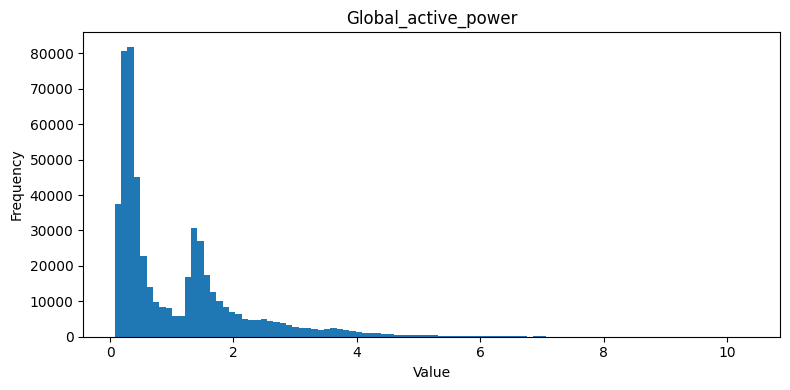

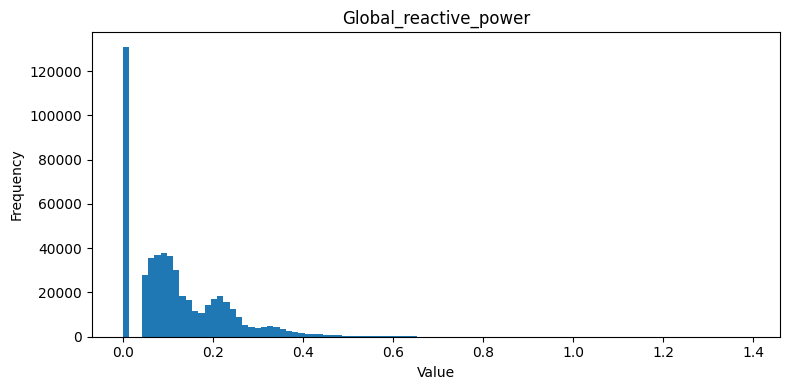

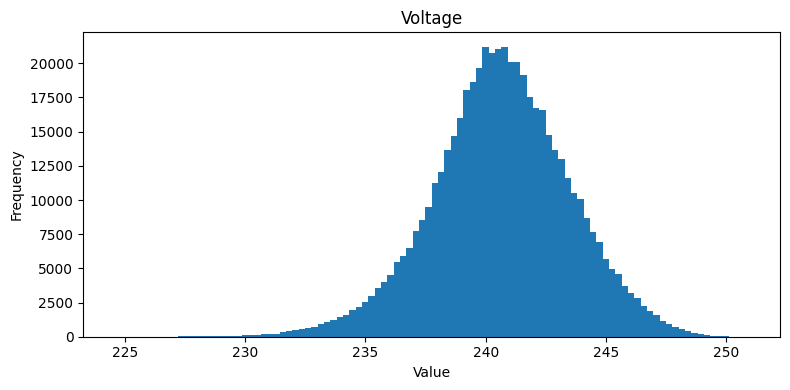

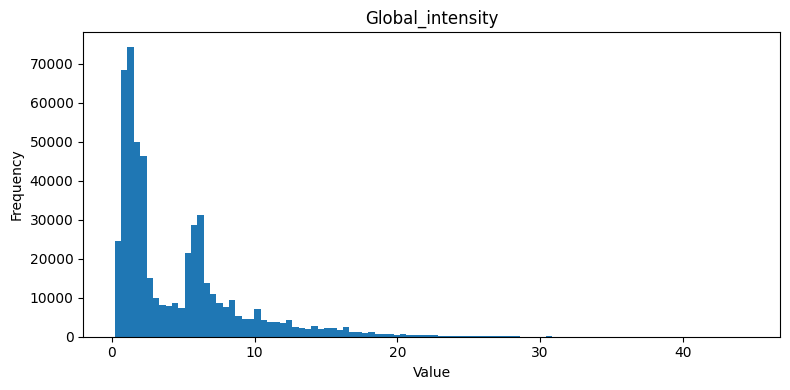

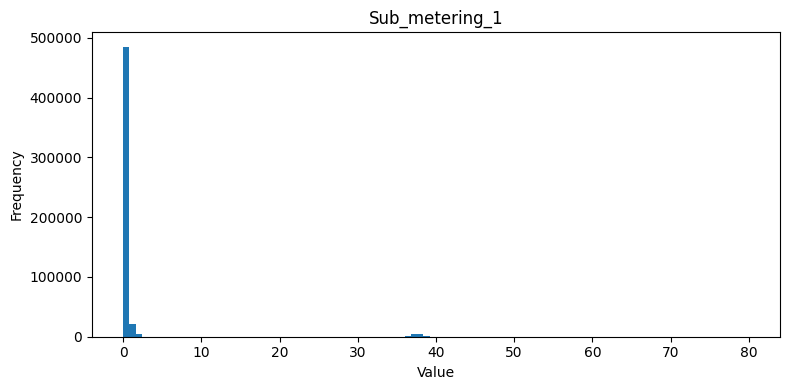

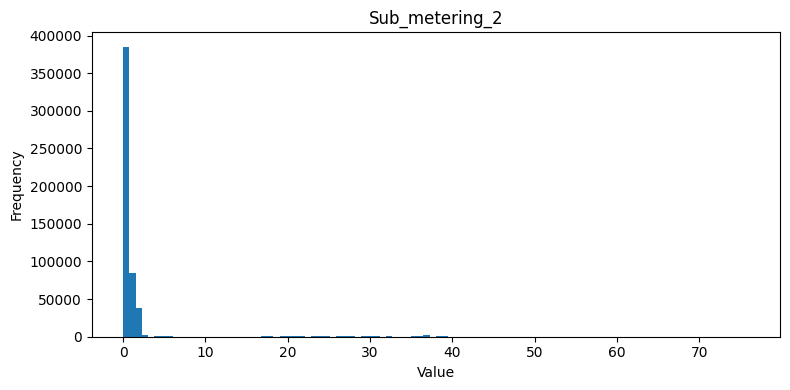

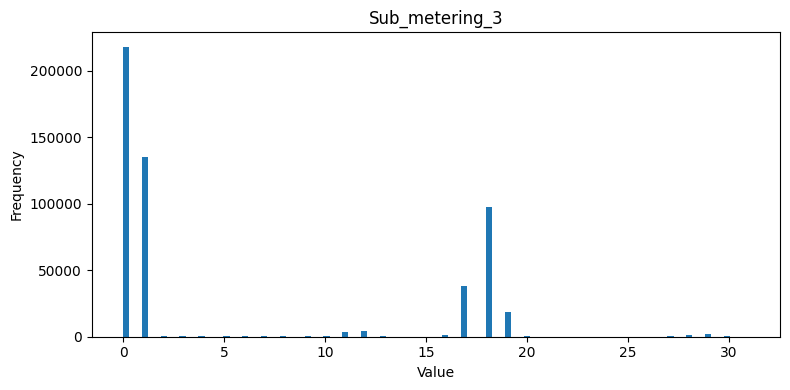

In [6]:
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df_2008[col].astype(float), bins=100)
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

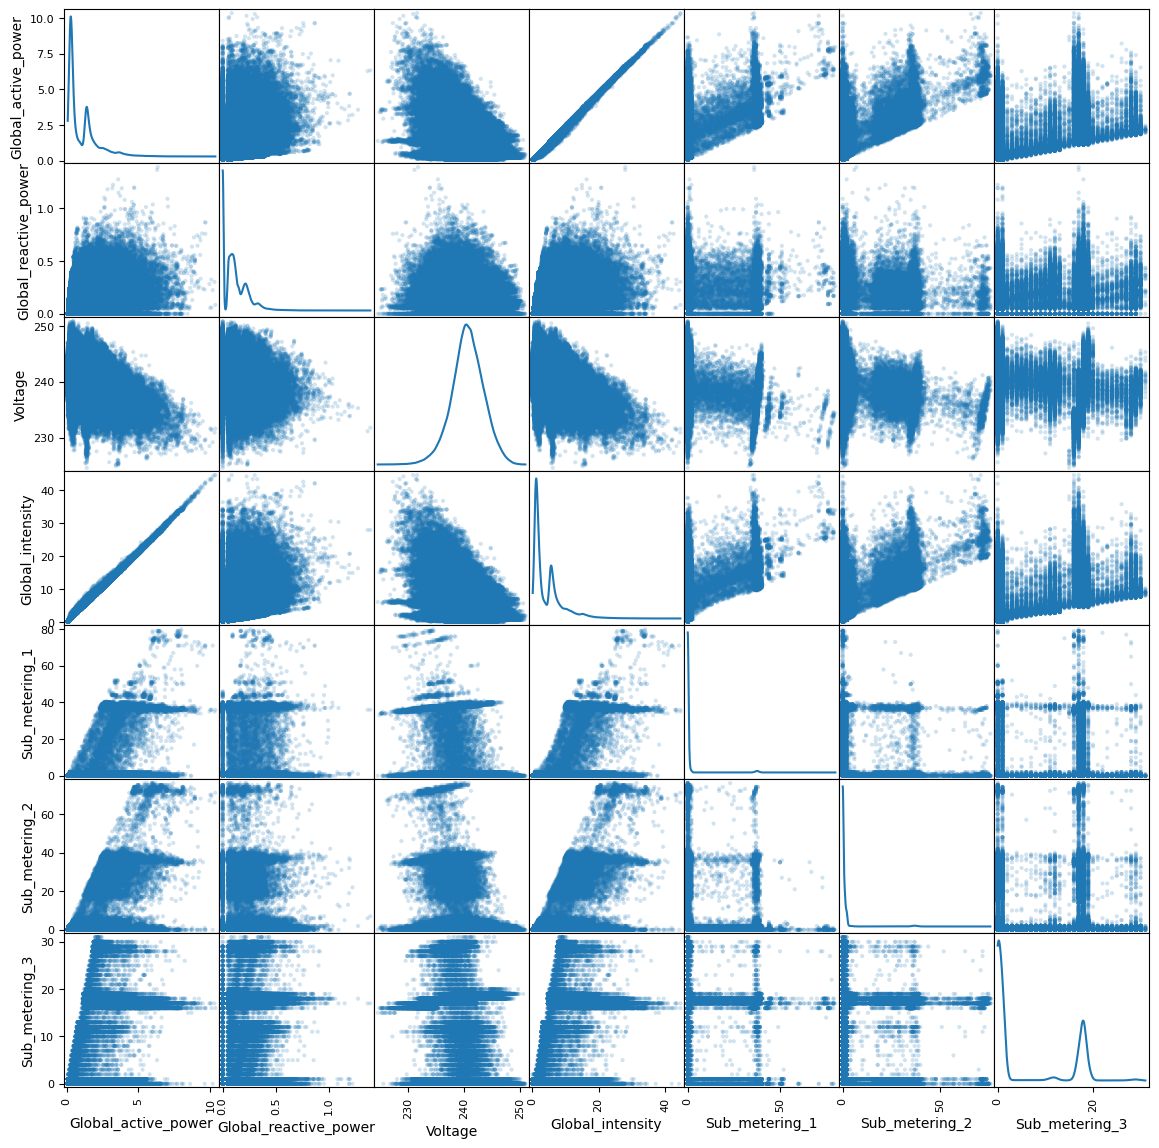

In [7]:
pd.plotting.scatter_matrix(df_2008[numeric_cols].astype(float), figsize=(14, 14), diagonal='kde', alpha=0.2)
plt.show()

## 4. Deciding variables
I have decided to use **Global_active_power, Global_reactive_power, and Voltage** as the variables in my model. These variables seem somewhat independent of each other, which will create interesting results.

Why I dropped Date/Time: These are non-numeric and not useful in the model.

Why I dropped Global_intensity: Based off the scatter matrix, Global_intensity is highly correlated with Global_active_power. I decided to exclude it because it would be pretty redundant to keep, as it won't really add anything new to the model.

Why I dropped Sub_metering_1/2/3: When reading the additional variable information, I found that these corresponde to the energy expended by the kitchen, laundry room, and boiler room. While this may be interesting, the histograms of the Sub_metering variables show that a large number of the values within these variables are 0. This indicates less throrough collection of the data for these variables, which may create noise and affect the model. I feel that it is better to ignore these and focus on other variables, which have more complete data.

In [8]:
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage']
features = df_2008.filter(cols)
features

,Global_active_power,Global_reactive_power,Voltage
0,1.620,0.070,241.25
1,1.626,0.072,241.74
2,1.622,0.072,241.52
3,1.612,0.070,240.82
4,1.612,0.070,240.80
...,...,...,...
526900,0.484,0.064,247.69
526901,0.482,0.064,247.35
526902,0.482,0.064,246.99
526903,0.480,0.064,246.52


## 5. Scale Variables

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## 6. Building Clustering Models
I ran various kmeans simulations that range from 2 to 10 clusters.

# 7. Identifying Ideal Clusters
First, I used the sum of squared errors (SSE). Then, I plotted it and looked for the "Elbow Point". However, it is unclear where the "Elbow Point" is, so I have to use another method.

I decided to use silhouette scores. However, 500k+ points takes too long to run, so I took a sample of 50k points. After plotting the silhouette scores, I found 2 clusters to have the highest silhouette score, and thus the ideal numver of clusters.

In [10]:
sse = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42).fit(X_scaled)
    print(kmeans.labels_)
    sse[k] = (
        kmeans.inertia_
    ) 


print(sse)

c:\Users\APR86\INFSCI0510-PC\.infsci\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\APR86\INFSCI0510-PC\.infsci\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\APR86\INFSCI0510-PC\.infsci\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\APR86\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) a

[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[3 3 3 ... 0 0 0]
[3 0 3 ... 4 4 4]
[2 2 2 ... 4 4 4]
[2 2 2 ... 4 4 4]
[0 0 0 ... 2 2 2]
[0 0 0 ... 2 2 2]
[0 0 0 ... 2 2 2]
{2: 1058777.9376857819, 3: 833972.9136529716, 4: 667237.2145395224, 5: 579258.4794302151, 6: 514519.7017201634, 7: 460550.8596885395, 8: 425261.09464542125, 9: 399698.8486112432, 10: 369935.7439074475}


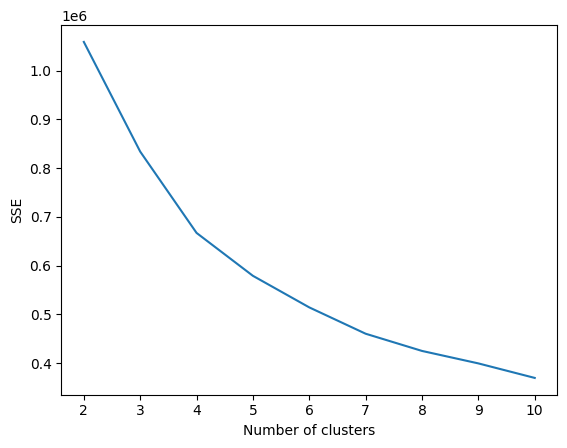

In [11]:
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

In [12]:
sample = features.sample(n=50000, random_state=42)
X_scaled_sample = scaler.fit_transform(sample.astype(float))

silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42).fit(X_scaled_sample)
    score = silhouette_score(X_scaled_sample, kmeans.labels_)
    silhouette_scores[k] = score
    print(f"For n_clusters = {k}, silhouette score is {score}")

For n_clusters = 2, silhouette score is 0.36145822255843735
For n_clusters = 3, silhouette score is 0.3270868227131105
For n_clusters = 4, silhouette score is 0.28807741844384843
For n_clusters = 5, silhouette score is 0.2726047128563768
For n_clusters = 6, silhouette score is 0.2787613763583952
For n_clusters = 7, silhouette score is 0.2888229820962019
For n_clusters = 8, silhouette score is 0.28584610211318534
For n_clusters = 9, silhouette score is 0.2831651249587878
For n_clusters = 10, silhouette score is 0.28560682553526706


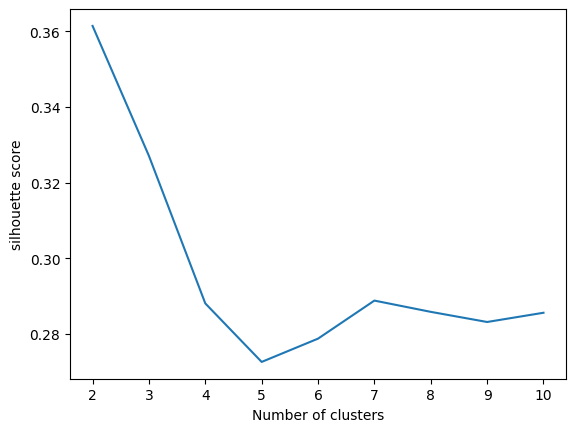

In [13]:
plt.figure()
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()))
plt.xlabel("Number of clusters")
plt.ylabel("silhouette score")
plt.show()

In [14]:
# 2 cluster
kmeans_2 = KMeans(n_clusters=2, max_iter=1000, random_state=42).fit(X_scaled)
features["clusters"] = kmeans_2.labels_
features['clusters'] = features['clusters'].map({0:'Low',1:'High'})
cluster_centers_2 = scaler.inverse_transform(kmeans_2.cluster_centers_)
df_centers_2 = pd.DataFrame(
    cluster_centers_2,
    columns=cols
)
df_centers_2

,Global_active_power,Global_reactive_power,Voltage
0,0.598941,0.091213,241.78154
1,2.228032,0.179756,237.90731


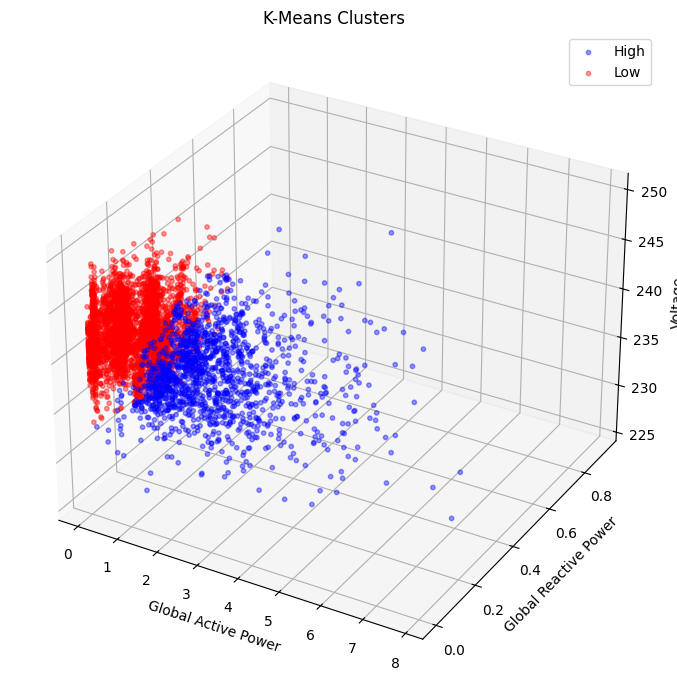

In [15]:
from mpl_toolkits.mplot3d import Axes3D

sample = features.sample(n=5000, random_state=42)
sample_labels = features.loc[sample.index, 'clusters'] # if clusters is in features
# or: sample_labels = df_2008.loc[sample.index, 'clusters']

color_map = {'Low': 'red', 'High' : 'blue'}

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10.colors
for cluster in sorted(sample_labels.unique()):
    mask = sample_labels == cluster
    ax.scatter(
        sample.loc[mask, 'Global_active_power'],
        sample.loc[mask, 'Global_reactive_power'],
        sample.loc[mask, 'Voltage'],
        color=color_map[cluster],
        label=f'{cluster}',
        alpha=0.4,
        s=10
    )

ax.set_xlabel('Global Active Power')
ax.set_ylabel('Global Reactive Power')
ax.set_zlabel('Voltage')
ax.set_title('K-Means Clusters')
ax.legend()
plt.tight_layout()
plt.show()

Since there are only 3 variables, we can plot the clusters on a 3d graph.

## 8. Interpretation

### What do these clusters represent?

These clusters represent two distinct electricity consumption "modes" for a single household throughout 2008.

The *Low* cluster captures periods of minimal electrical activity, most likely measured when the house is vacant or during the night. Data points in this cluster tends to have lower global active/reactive power.

The *High* cluster represents periods of higer electrical activity, usually where multiple appliances are running simulteneously. In comparison to the low cluster, they have significantly higher power demand (SEE CELL 14).

### How can this information be used?

Since data comes froma single household, the cluster can be used to build a profile of that household's energy habits. By charting which periods tend to fall into the High clusters, we can make suggestions to improve energy efficiency. For example, they can shift energy-intesnivve tasks to off-peak hours to reduce electricity bills.